In [ ]:
---
title: "quick_example"
engine: julia
format: html
---

In [1]:
isfile("/Users/eo/Dev/textbook_notes/JuliaForDataAnalysis/movies.dat")

true

In [2]:
movies = readlines("/Users/eo/Dev/textbook_notes/JuliaForDataAnalysis/movies.dat")

3096-element Vector{String}:
 "0002844::Fantômas - À l'ombre de la guillotine (1913)::Crime|Drama"
 "0007264::The Rink (1916)::Comedy|Short"
 "0008133::The Immigrant (1917)::Short|Comedy|Drama|Romance"
 "0012349::The Kid (1921)::Comedy|Drama|Family"
 "0013427::Nanook of the North (1922)::Documentary"
 "0014142::The Hunchback of Notre Dame (1923)::Drama|Romance"
 "0014538::Three Ages (1923)::Comedy"
 "0014872::Entr'acte (1924)::Short"
 "0015163::The Navigator (1924)::Action|Comedy"
 "0015324::Sherlock Jr. (1924)::Comedy|Fantasy"
 ⋮
 "2646378::The Frankenstein Theory (2013)::Horror|Sci-Fi"
 "2649128::Metro (2013)::Thriller"
 "2670226::Jîn (2013)::Drama"
 "2700330::The Two Escobars (2010)::Documentary"
 "2735466::Pickett's Charge (2012)::Short|Comedy|Drama|Family"
 "2748368::Neil (2013)::Short|Comedy"
 "2750600::A Different Tree (2013)::Short|Drama|Family"
 "2763252::Broken Night (2013)::Short|Drama"
 "2769592::Kiss Shot Truth or Dare (2013)::Short"

In [3]:
movie1 = first(movies)

"0002844::Fantômas - À l'ombre de la guillotine (1913)::Crime|Drama"

In [4]:
movie1_parts = split(movie1, "::")

3-element Vector{SubString{String}}:
 "0002844"
 "Fantômas - À l'ombre de la guillotine (1913)"
 "Crime|Drama"

In [5]:
supertype(String)

AbstractString

In [6]:
supertype(SubString{String})

AbstractString

When annotating types of function arguments that should be strings, use `AbstractString` instead of `String` (unless you really require the `String` type, which is rare.)

For instance, this is a good style of defining a function:
```julia
suffix_bang(s::AbstractString) = s * "!"
```
Using a `String` instead of `AbstractString` in this definition isnt recommended, as then this function wouldnt work with `SubString{String}` arguments!

In [7]:
movie1_parts[2]

"Fantômas - À l'ombre de la guillotine (1913)"

In [8]:
rx = r"(.+) \((\d{4})\)$"

r"(.+) \((\d{4})\)$"

In [9]:
m = match(rx, movie1_parts[2])

RegexMatch("Fantômas - À l'ombre de la guillotine (1913)", 1="Fantômas - À l'ombre de la guillotine", 2="1913")

In [10]:
m[1]

"Fantômas - À l'ombre de la guillotine"

In [11]:
m[2]

"1913"

In [12]:
parse(Int, m[2])

1913

In [13]:
function parseline(line::AbstractString)
    parts = split(line, "::")
    m = match(r"(.+) \((\d{4})\)", parts[2])
    return (id=parts[1], name=m[1], year=parse(Int, m[2]), genres=split(parts[3], "|"))
end

parseline (generic function with 1 method)

In [14]:
record1 = parseline(movie1)

(id = "0002844", name = "Fantômas - À l'ombre de la guillotine", year = 1913, genres = SubString{String}["Crime", "Drama"])

In [15]:
codeunits("a")

1-element Base.CodeUnits{UInt8, String}:
 0x61

In [16]:
codeunits("?")

1-element Base.CodeUnits{UInt8, String}:
 0x3f

In [17]:
codeunits("∀")

3-element Base.CodeUnits{UInt8, String}:
 0xe2
 0x88
 0x80

In [18]:
word = first(record1.name, 8)

"Fantômas"

In [19]:
record1.name[1:8]

"Fantôma"

In [20]:
for i in eachindex(word)
    println(i, ": ", word[i])
end

1: F
2: a
3: n
4: t
5: ô
7: m
8: a
9: s


In [21]:
codeunits("ô")

2-element Base.CodeUnits{UInt8, String}:
 0xc3
 0xb4

In [22]:
codeunits("Fantômas")

9-element Base.CodeUnits{UInt8, String}:
 0x46
 0x61
 0x6e
 0x74
 0xc3
 0xb4
 0x6d
 0x61
 0x73

In [23]:
records = parseline.(movies)

3096-element Vector{@NamedTuple{id::SubString{String}, name::SubString{String}, year::Int64, genres::Vector{SubString{String}}}}:
 (id = "0002844", name = "Fantômas - À l'ombre de la guillotine", year = 1913, genres = ["Crime", "Drama"])
 (id = "0007264", name = "The Rink", year = 1916, genres = ["Comedy", "Short"])
 (id = "0008133", name = "The Immigrant", year = 1917, genres = ["Short", "Comedy", "Drama", "Romance"])
 (id = "0012349", name = "The Kid", year = 1921, genres = ["Comedy", "Drama", "Family"])
 (id = "0013427", name = "Nanook of the North", year = 1922, genres = ["Documentary"])
 (id = "0014142", name = "The Hunchback of Notre Dame", year = 1923, genres = ["Drama", "Romance"])
 (id = "0014538", name = "Three Ages", year = 1923, genres = ["Comedy"])
 (id = "0014872", name = "Entr'acte", year = 1924, genres = ["Short"])
 (id = "0015163", name = "The Navigator", year = 1924, genres = ["Action", "Comedy"])
 (id = "0015324", name = "Sherlock Jr.", year = 1924, genres = ["Comedy

In [24]:
genres = String[]

String[]

In [25]:
for record in records
    append!(genres, record.genres)
end

In [26]:
genres

8121-element Vector{String}:
 "Crime"
 "Drama"
 "Comedy"
 "Short"
 "Short"
 "Comedy"
 "Drama"
 "Romance"
 "Comedy"
 "Drama"
 ⋮
 "Family"
 "Short"
 "Comedy"
 "Short"
 "Drama"
 "Family"
 "Short"
 "Drama"
 "Short"

In [27]:
using FreqTables

In [28]:
table = freqtable(genres)

25-element Named Vector{Int64}
Dim1        │ 
────────────┼─────
            │   14
Action      │  635
Adventure   │  443
Animation   │  137
Biography   │  166
Comedy      │ 1001
Crime       │  550
Documentary │  126
⋮                ⋮
News        │    4
Romance     │  558
Sci-Fi      │  305
Short       │   46
Sport       │   84
Thriller    │  910
War         │  126
Western     │   35

In [29]:
sort!(table)

25-element Named Vector{Int64}
Dim1        │ 
────────────┼─────
News        │    4
Film-Noir   │   13
            │   14
Western     │   35
Short       │   46
Musical     │   58
Music       │   83
Sport       │   84
⋮                ⋮
Horror      │  325
Adventure   │  443
Crime       │  550
Romance     │  558
Action      │  635
Thriller    │  910
Comedy      │ 1001
Drama       │ 1583

In [30]:
years = [record.year for record in records]

3096-element Vector{Int64}:
 1913
 1916
 1917
 1921
 1922
 1923
 1923
 1924
 1924
 1924
    ⋮
 2013
 2013
 2013
 2010
 2012
 2013
 2013
 2013
 2013

In [31]:
has_drama = ["Drama" in record.genres for record in records]

3096-element Vector{Bool}:
 1
 0
 1
 1
 0
 1
 0
 0
 0
 0
 ⋮
 0
 0
 1
 0
 1
 0
 1
 1
 0

In [32]:
drama_prop = proptable(years, has_drama; margins=1)

93×2 Named Matrix{Float64}
Dim1 ╲ Dim2 │    false      true
────────────┼───────────────────
1913        │      0.0       1.0
1916        │      1.0       0.0
1917        │      0.0       1.0
1921        │      0.0       1.0
1922        │      1.0       0.0
1923        │      0.5       0.5
1924        │      1.0       0.0
1926        │      1.0       0.0
⋮                    ⋮         ⋮
2006        │ 0.426357  0.573643
2007        │ 0.492063  0.507937
2008        │ 0.424051  0.575949
2009        │ 0.432432  0.567568
2010        │ 0.451754  0.548246
2011        │ 0.484472  0.515528
2012        │ 0.577017  0.422983
2013        │ 0.623529  0.376471

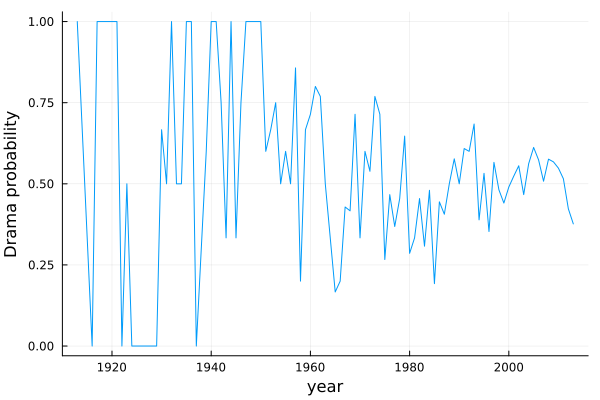

In [40]:
using Plots

plot(names(drama_prop, 1), drama_prop[:, 2]; legend=false, xlabel="year", ylabel="Drama probability")

### Creating symbols


In [41]:
s1 = Symbol("x")


:x

In [42]:
s2 = Symbol("hello world")

Symbol("hello world")

In [43]:
s3 = Symbol("x", 1)

:x1

All three values bound to variables to s1, s2 & s3 have the type `Symbol`:

In [44]:
println(typeof(s1))
println(typeof(s2))
println(typeof(s3))

Symbol
Symbol
Symbol


Notice when you pass several values to `Symbol`, their string representations are concatenated.
Second, and more importantly, you can see that symbols are displayed using two styles. First is `:x`, and `:x1`, and the second is more verbose:
```julia
Symbol("hello world!")
```

In [ ]:
supertype(Symbol)

Any

Notice that its type `Any`, not `AbstractString`. This means that no function that operate on strings will work with values having a `Symbol` type. The only operations that in practice is useful on symbols in typical data science workflows is an equality comparison.

In [46]:
:x == :x

true

In [47]:
using BenchmarkTools

In [48]:
str = string.("x", 1:10^6)

1000000-element Vector{String}:
 "x1"
 "x2"
 "x3"
 "x4"
 "x5"
 "x6"
 "x7"
 "x8"
 "x9"
 "x10"
 ⋮
 "x999992"
 "x999993"
 "x999994"
 "x999995"
 "x999996"
 "x999997"
 "x999998"
 "x999999"
 "x1000000"

In [49]:
symb = Symbol.(str)

1000000-element Vector{Symbol}:
 :x1
 :x2
 :x3
 :x4
 :x5
 :x6
 :x7
 :x8
 :x9
 :x10
 ⋮
 :x999992
 :x999993
 :x999994
 :x999995
 :x999996
 :x999997
 :x999998
 :x999999
 :x1000000

In [50]:
@btime "x" in $str;

  10.824 ms (0 allocations: 0 bytes)


In [51]:
@btime :x in $symb;

  370.542 μs (0 allocations: 0 bytes)


As a general rule of thumb, the benchmark shows that the lookup using symbols is over 10 times faster than when we use strings. How? Internally Julia keeps a global pool of all symbols. If you introduce a new `Symbol`, Julia first checks whether it is already present in this pool, and if so, Julia reuses it. So when you compare two symbols, you can compare their address in memory without having to check their content.
Note: defining many identical symbols doesnt allocate new memory, as they will point to the same reference value. On the other hand, once `Symbol` is allocated in the global pool, it stays there until the end of the Julia session, which sometimes might look like a memory leak in the program if you create a very large number of unique symbols.